In [2]:
import pandas as pd
df = pd.read_excel("online_retail_II.xlsx")

In [3]:
print(df.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [6]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


In [8]:
df = df.dropna(subset=["Customer ID"])

In [9]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0
Country,0


In [10]:
df[df["Quantity"] < 0].shape

(9839, 8)

In [11]:
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

In [12]:
df[df["Quantity"] < 0].shape

(0, 8)

In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [14]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

In [15]:
import datetime
reference_date = df["InvoiceDate"].max() + datetime.timedelta(days=1)

In [16]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [17]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [18]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
12346.0,165,11,372.86,1,4,2,142
12347.0,3,2,1323.32,4,2,3,423
12348.0,74,1,222.16,2,1,1,211
12349.0,43,3,2671.14,3,3,4,334
12351.0,11,1,300.93,4,1,1,411


In [19]:
rfm["Segment"] = "Regular"

rfm.loc[(rfm["R_score"] == 4) &
        (rfm["F_score"] == 4) &
        (rfm["M_score"] == 4), "Segment"] = "Top Customers"

rfm.loc[(rfm["R_score"] == 4) &
        (rfm["F_score"] >= 3), "Segment"] = "Loyal Customers"

rfm.loc[(rfm["R_score"] <= 2), "Segment"] = "At Risk"

In [20]:
rfm["Segment"].value_counts()

,count
Segment,
At Risk,3236
Regular,1076


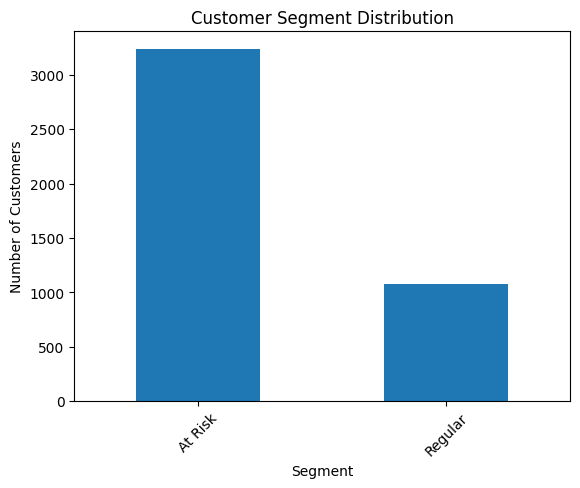

In [21]:
import matplotlib.pyplot as plt
segment_counts = rfm["Segment"].value_counts()
plt.figure()

segment_counts.plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

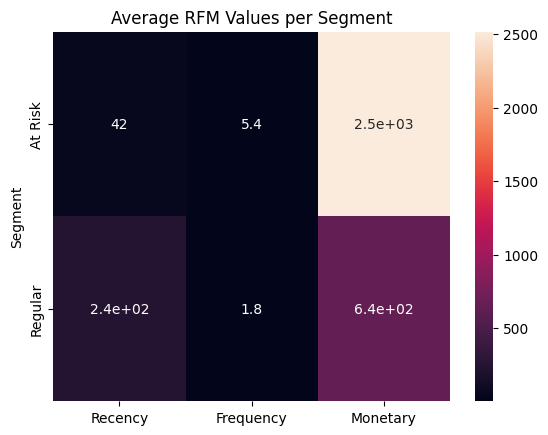

In [22]:
import seaborn as sns

rfm_numeric = rfm.copy()
rfm_numeric[["Recency","Frequency","Monetary"]] = \
rfm_numeric[["Recency","Frequency","Monetary"]].astype(float)

segment_avg = rfm_numeric.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()

plt.figure()
sns.heatmap(segment_avg, annot=True)
plt.title("Average RFM Values per Segment")
plt.show()